# Assignment 4 — Volatility Timing in the U.S. Stock Market

This notebook builds every table and figure used in the report. It is idempotent: running top-to-bottom regenerates all artefacts in `tables/` and `figures/`.

## 1) Setup and paths

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model

ROOT = Path.cwd()
if ROOT.name != "Assignment4":
    ROOT = ROOT / "Assignment4"
TABLE_DIR = ROOT / "tables"; TABLE_DIR.mkdir(exist_ok=True)
FIGURE_DIR = ROOT / "figures"; FIGURE_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})
print(f"ROOT = {ROOT}")

ROOT = /Users/user/Projects/Econometrics-II/Assignment4


## 2) Load data and construct $x_t$
The Excel file gives monthly log returns and risk-free rate (in % per month). We build the log excess return $x_t = \mathrm{mkt}_t - \mathrm{rf}_t$ and verify the supplied benchmark `xs_scaled_bt`.

In [2]:
raw = pd.read_excel(ROOT / "Assignment_4.xlsx")
raw = raw.rename(columns={"Unnamed: 0": "period", "xs_scaled_b": "xs_scaled_bt"})

def parse_period(s):
    m = re.match(r"\s*(\d{4})\s*\(\s*(\d{1,2})\s*\)\s*", s)
    return pd.Timestamp(year=int(m.group(1)), month=int(m.group(2)), day=1) + pd.offsets.MonthEnd(0)

raw["date"] = raw["period"].apply(parse_period)
df = raw.set_index("date").sort_index()
df["x"] = df["mkt"] - df["rf"]
T = len(df)
print(f"Sample: {df.index[0]:%Y-%m} to {df.index[-1]:%Y-%m}, T = {T}")

sigma_bar = 10.0 / np.sqrt(12)
expanding_sd = df["x"].expanding(min_periods=1).std().shift(1)
xs_scaled_check = (sigma_bar / expanding_sd) * df["x"]
diff = (xs_scaled_check - df["xs_scaled_bt"]).abs().max()
print(f"max|recomputed - provided xs_scaled_bt| = {diff:.3e}  (tiny rounding only)")

Sample: 1926-07 to 2026-02, T = 1196
max|recomputed - provided xs_scaled_bt| = 9.064e-05  (tiny rounding only)


## 3) Graphical analysis — Figure 1 and Figure 2

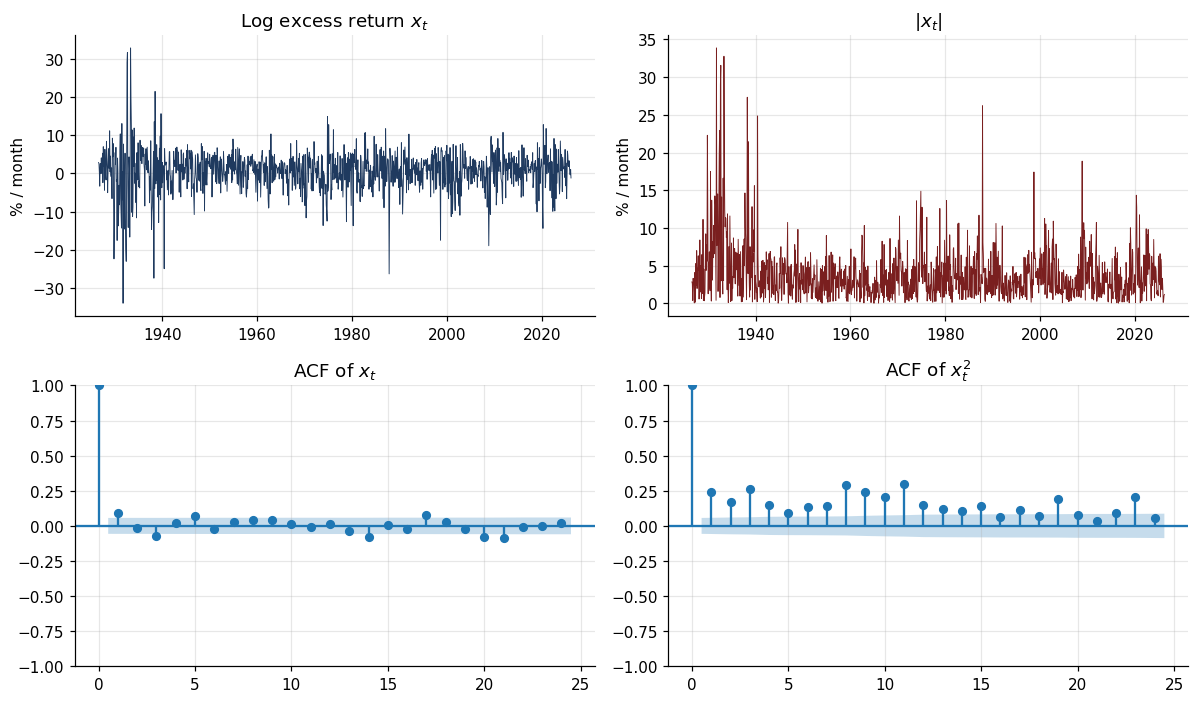

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
ax = axes[0, 0]; ax.plot(df.index, df["x"], lw=0.6, color="#1f3a5f"); ax.set_title(r"Log excess return $x_t$"); ax.set_ylabel("% / month")
ax = axes[0, 1]; ax.plot(df.index, df["x"].abs(), lw=0.6, color="#7a1f1f"); ax.set_title(r"$|x_t|$"); ax.set_ylabel("% / month")
plot_acf(df["x"].dropna(),    lags=24, ax=axes[1, 0], title=r"ACF of $x_t$")
plot_acf(df["x"].dropna()**2, lags=24, ax=axes[1, 1], title=r"ACF of $x_t^2$")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig1_series_panel.pdf", bbox_inches="tight"); plt.show()

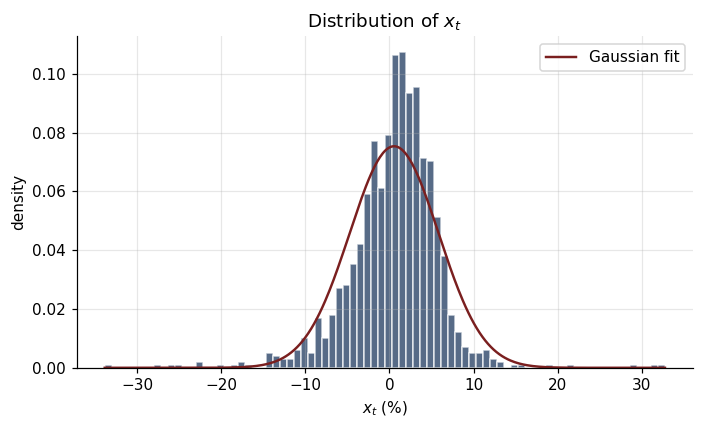

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 4))
x = df["x"].dropna().values
ax.hist(x, bins=80, density=True, alpha=0.75, color="#1f3a5f", edgecolor="white")
xs = np.linspace(x.min(), x.max(), 400)
ax.plot(xs, stats.norm.pdf(xs, x.mean(), x.std()), color="#7a1f1f", lw=1.6, label="Gaussian fit")
ax.set_xlabel(r"$x_t$ (%)"); ax.set_ylabel("density"); ax.set_title(r"Distribution of $x_t$"); ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig2_hist.pdf", bbox_inches="tight"); plt.show()

## 4) Descriptive statistics and ARCH-LM test (Tables 0 and 1)
ARCH-LM regresses $\hat\varepsilon_t^2$ on $h$ of its own lags; under $H_0$ of no ARCH, $\zeta_{\mathrm{ARCH}} = T R^2 \xrightarrow{d} \chi^2(h)$.

In [5]:
desc = df[["mkt", "rf", "x"]].describe().T[["mean", "std", "min", "max"]]
desc["skew"] = df[["mkt", "rf", "x"]].skew()
desc["kurt"] = df[["mkt", "rf", "x"]].kurt()
print(desc.round(3))

with open(TABLE_DIR / "table0_descriptives.tex", "w") as f:
    f.write(r"\begin{tabular}{lrrrrrr}\toprule" + "\n")
    f.write(r"Series & Mean & Std & Min & Max & Skew & Ex. Kurt \\\midrule" + "\n")
    name_map = {"mkt": r"$\text{mkt}_t$", "rf": r"$\text{rf}_t$", "x": r"$x_t$"}
    for k in ["mkt", "rf", "x"]:
        r = desc.loc[k]
        f.write(f"{name_map[k]} & {r['mean']:.3f} & {r['std']:.3f} & {r['min']:.2f} & {r['max']:.2f} & {r['skew']:.2f} & {r['kurt']:.2f}" + r" \\" + "\n")
    f.write(r"\bottomrule\end{tabular}" + "\n")

      mean    std     min     max   skew   kurt
mkt  0.817  5.289 -33.841  32.866 -0.552  6.525
rf   0.269  0.248  -0.060   1.341  1.090  1.400
x    0.548  5.297 -33.871  32.766 -0.522  6.482


In [6]:
resid = df["x"] - df["x"].mean()
arch_rows = []
for h in (1, 5, 12):
    stat, pval, *_ = het_arch(resid.dropna(), nlags=h)
    arch_rows.append((h, stat, pval))
arch_lm_df = pd.DataFrame(arch_rows, columns=["h", "stat", "pval"])
print(arch_lm_df)

with open(TABLE_DIR / "table1_arch_lm.tex", "w") as f:
    f.write(r"\begin{tabular}{lcc}\toprule" + "\n")
    f.write(r"Lags $h$ & $\zeta_{\mathrm{ARCH}}=T R^2$ & $p$-value \\\midrule" + "\n")
    for _, r in arch_lm_df.iterrows():
        f.write(f"{int(r['h'])} & {r['stat']:.2f} & {r['pval']:.3g}" + r" \\" + "\n")
    f.write(r"\bottomrule\end{tabular}" + "\n")

    h        stat          pval
0   1   65.268826  6.534692e-16
1   5  134.429165  2.730814e-27
2  12  236.706210  8.038905e-44


## 5) Estimate candidate models — Table 2
We estimate by (Quasi-)MLE with robust ('sandwich') standard errors. Models compared: ARCH(1), ARCH(5), GARCH(1,1), GJR-GARCH(1,1) under Gaussian innovations, and GJR-GARCH(1,1) under Student-$t(\nu)$ innovations.

In [7]:
x_pct = df["x"].dropna()
specs = {
    "ARCH(1)":     arch_model(x_pct, mean="Constant", vol="ARCH",  p=1),
    "ARCH(5)":     arch_model(x_pct, mean="Constant", vol="ARCH",  p=5),
    "GARCH(1,1)":  arch_model(x_pct, mean="Constant", vol="GARCH", p=1, q=1),
    "GJR(1,1)":    arch_model(x_pct, mean="Constant", vol="GARCH", p=1, o=1, q=1),
    "GJR(1,1)-t":  arch_model(x_pct, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t"),
}
fits = {name: m.fit(disp="off", show_warning=False) for name, m in specs.items()}

def model_diag(res):
    z = res.std_resid.dropna(); z2 = z ** 2
    lb_z  = acorr_ljungbox(z,  lags=[12], return_df=True).iloc[0]["lb_pvalue"]
    lb_z2 = acorr_ljungbox(z2, lags=[12], return_df=True).iloc[0]["lb_pvalue"]
    arch_p = het_arch(z, nlags=12)[1]
    jb = stats.jarque_bera(z); jb_p = float(jb.pvalue)
    return dict(logL=res.loglikelihood, AIC=res.aic, BIC=float(res.bic),
                lb_z=float(lb_z), lb_z2=float(lb_z2), arch12_p=float(arch_p), jb_p=jb_p)

diagnostics = {n: model_diag(r) for n, r in fits.items()}
for n, r in fits.items():
    print(n, dict(r.params.round(4)), {k: round(v,4) for k,v in diagnostics[n].items()})

ARCH(1) {'mu': np.float64(0.7324), 'omega': np.float64(21.966), 'alpha[1]': np.float64(0.2054)} {'logL': -3646.79, 'AIC': 7299.58, 'BIC': 7314.8402, 'lb_z': 0.0849, 'lb_z2': 0.0, 'arch12_p': 0.0, 'jb_p': 0.0}
ARCH(5) {'mu': np.float64(0.6937), 'omega': np.float64(10.498), 'alpha[1]': np.float64(0.1034), 'alpha[2]': np.float64(0.1591), 'alpha[3]': np.float64(0.1896), 'alpha[4]': np.float64(0.1702), 'alpha[5]': np.float64(0.0305)} {'logL': -3560.356, 'AIC': 7134.712, 'BIC': 7170.3192, 'lb_z': 0.3447, 'lb_z2': 0.4905, 'arch12_p': 0.4594, 'jb_p': 0.0}
GARCH(1,1) {'mu': np.float64(0.7165), 'omega': np.float64(0.7336), 'alpha[1]': np.float64(0.1346), 'beta[1]': np.float64(0.8451)} {'logL': -3527.7009, 'AIC': 7063.4019, 'BIC': 7083.7488, 'lb_z': 0.299, 'lb_z2': 0.9682, 'arch12_p': 0.9691, 'jb_p': 0.0}
GJR(1,1) {'mu': np.float64(0.6388), 'omega': np.float64(1.0294), 'alpha[1]': np.float64(0.0553), 'gamma[1]': np.float64(0.1249), 'beta[1]': np.float64(0.8395)} {'logL': -3521.7253, 'AIC': 7053.4

In [8]:
def get(p, k): return p[k] if k in p.index else np.nan
def get_se(r, k): return r.std_err[k] if k in r.std_err.index else np.nan

rows = []
for name, r in fits.items():
    p = r.params; d = diagnostics[name]
    alpha = get(p, "alpha[1]"); beta = get(p, "beta[1]"); gamma = get(p, "gamma[1]")
    if name.startswith("ARCH"):
        alpha = sum(p[k] for k in p.index if k.startswith("alpha"))
    pers = (alpha if not np.isnan(alpha) else 0) + (beta if not np.isnan(beta) else 0) + (0.5*gamma if not np.isnan(gamma) else 0)
    rows.append(dict(model=name,
        mu=get(p,"mu"), mu_se=get_se(r,"mu"),
        omega=get(p,"omega"), omega_se=get_se(r,"omega"),
        alpha=alpha, alpha_se=get_se(r,"alpha[1]") if not name.startswith("ARCH") else np.nan,
        gamma=gamma, gamma_se=get_se(r,"gamma[1]"),
        beta=beta, beta_se=get_se(r,"beta[1]"),
        nu=get(p,"nu"), nu_se=get_se(r,"nu"),
        pers=pers, **d))
comp = pd.DataFrame(rows).set_index("model")
print(comp.round(3))

def fmt(v,d=3):
    return "--" if (v is None or (isinstance(v,float) and np.isnan(v))) else f"{v:.{d}f}"
def fmt_se(v):
    return "" if (v is None or (isinstance(v,float) and np.isnan(v))) else f"({v:.3f})"
def fmt_p(v):
    if np.isnan(v): return "--"
    return f"{v:.3f}" if v >= 0.001 else r"$<$0.001"

cols = list(comp.index)
def row(label, key, se_key=None, d=3):
    cells = [label] + [fmt(comp.loc[c,key], d) for c in cols]
    line = " & ".join(cells) + r" \\"
    if se_key:
        se_cells = [""] + [fmt_se(comp.loc[c, se_key]) for c in cols]
        line += "\n" + " & ".join(se_cells) + r" \\"
    return line

with open(TABLE_DIR / "table2_models.tex", "w") as f:
    n = len(cols)
    f.write(r"\begin{tabular}{l" + "c"*n + r"}\toprule" + "\n")
    f.write("Parameter & " + " & ".join(cols) + r" \\\midrule" + "\n")
    for label, k, se in [(r"$\mu$","mu","mu_se"), (r"$\omega$","omega","omega_se"),
                         (r"$\alpha$","alpha","alpha_se"), (r"$\kappa$ (asym.)","gamma","gamma_se"),
                         (r"$\beta$","beta","beta_se")]:
        f.write(row(label, k, se) + "\n")
    f.write(row(r"$\nu$", "nu", "nu_se", d=2) + "\n")
    f.write(r"\midrule" + "\n")
    f.write("Persistence & " + " & ".join(fmt(comp.loc[c,"pers"]) for c in cols) + r" \\" + "\n")
    f.write(r"$\log L$ & " + " & ".join(f"{comp.loc[c,'logL']:.1f}" for c in cols) + r" \\" + "\n")
    f.write("AIC & " + " & ".join(f"{comp.loc[c,'AIC']:.1f}" for c in cols) + r" \\" + "\n")
    f.write("BIC & " + " & ".join(f"{comp.loc[c,'BIC']:.1f}" for c in cols) + r" \\" + "\n")
    f.write(r"\midrule" + "\n")
    f.write(r"LB$(\hat z,12)$ $p$ & "    + " & ".join(fmt_p(comp.loc[c,'lb_z'])    for c in cols) + r" \\" + "\n")
    f.write(r"LB$(\hat z^2,12)$ $p$ & "  + " & ".join(fmt_p(comp.loc[c,'lb_z2'])   for c in cols) + r" \\" + "\n")
    f.write(r"ARCH$(12)$ $p$ & "           + " & ".join(fmt_p(comp.loc[c,'arch12_p']) for c in cols) + r" \\" + "\n")
    f.write(r"JB $p$ & "                   + " & ".join(fmt_p(comp.loc[c,'jb_p'])    for c in cols) + r" \\" + "\n")
    f.write(r"\bottomrule\end{tabular}" + "\n")
print("table2_models.tex written")

               mu  mu_se   omega  omega_se  alpha  alpha_se  gamma  gamma_se  \
model                                                                          
ARCH(1)     0.732  0.157  21.966     2.610  0.205       NaN    NaN       NaN   
ARCH(5)     0.694  0.145  10.498     2.521  0.653       NaN    NaN       NaN   
GARCH(1,1)  0.716  0.125   0.734     0.292  0.135     0.026    NaN       NaN   
GJR(1,1)    0.639  0.120   1.029     0.516  0.055     0.035  0.125     0.070   
GJR(1,1)-t  0.858  0.123   1.567     0.554  0.030     0.022  0.179     0.061   

             beta  beta_se     nu  nu_se   pers      logL       AIC       BIC  \
model                                                                           
ARCH(1)       NaN      NaN    NaN    NaN  0.205 -3646.790  7299.580  7314.840   
ARCH(5)       NaN      NaN    NaN    NaN  0.653 -3560.356  7134.712  7170.319   
GARCH(1,1)  0.845    0.028    NaN    NaN  0.980 -3527.701  7063.402  7083.749   
GJR(1,1)    0.840    0.039    NaN 

## 6) Preferred model — Table 3
GJR-GARCH(1,1) with Student-$t(\nu)$ innovations is selected: the asymmetry parameter $\kappa$ is highly significant, AIC/BIC are lowest, and the standardized residuals pass ARCH/LB diagnostics.

In [9]:
PREF = "GJR(1,1)-t"
pref = fits[PREF]
print(pref.summary())

with open(TABLE_DIR / "table3_preferred.tex", "w") as f:
    f.write(r"\begin{tabular}{lrr}\toprule" + "\n")
    f.write(r"Parameter & Estimate & Robust SE \\\midrule" + "\n")
    name_map = {"mu": r"$\mu$", "omega": r"$\omega$", "alpha[1]": r"$\alpha$",
                "gamma[1]": r"$\kappa$", "beta[1]": r"$\beta$", "nu": r"$\nu$"}
    for k in ["mu","omega","alpha[1]","gamma[1]","beta[1]","nu"]:
        f.write(f"{name_map[k]} & {pref.params[k]:.4f} & {pref.std_err[k]:.4f}" + r" \\" + "\n")
    f.write(r"\midrule" + "\n")
    a = pref.params["alpha[1]"]; g = pref.params["gamma[1]"]; b = pref.params["beta[1]"]
    f.write(r"Persistence $\alpha+\beta+\tfrac12\kappa$ & " + f"{a+b+0.5*g:.4f}" + r" & \\" + "\n")
    f.write(r"$\log L$ & " + f"{pref.loglikelihood:.2f}" + r" & \\" + "\n")
    f.write(r"$T$ & " + f"{int(pref.nobs)}" + r" & \\" + "\n")
    f.write(r"\bottomrule\end{tabular}" + "\n")

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                            x   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3487.43
Distribution:      Standardized Student's t   AIC:                           6986.87
Method:                  Maximum Likelihood   BIC:                           7017.39
                                              No. Observations:                 1196
Date:                      Sat, May 16 2026   Df Residuals:                     1195
Time:                              11:16:43   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0

## 7) Construct $x^*_t$ and compare to unscaled and benchmark — Table 4

In [10]:
sigma_hat = pref.conditional_volatility
x_star = (sigma_bar / sigma_hat) * x_pct

mask = df["xs_scaled_bt"].notna()
panel = pd.DataFrame({
    "x":      df.loc[mask, "x"],
    "x_star": x_star.reindex(df.index).loc[mask],
    "xs_bt":  df.loc[mask, "xs_scaled_bt"],
}).dropna()
print(f"Panel: {len(panel)} obs from {panel.index[0]:%Y-%m} to {panel.index[-1]:%Y-%m}")

def perf(s):
    mu = s.mean(); sd = s.std()
    return dict(mean=mu, sd=sd, sr=mu/sd*np.sqrt(12),
                skew=s.skew(), kurt=s.kurt(), min=s.min(), max=s.max())
perf_df = pd.DataFrame({c: perf(panel[c]) for c in panel.columns}).T
print(perf_df.round(3))

with open(TABLE_DIR / "table4_performance.tex", "w") as f:
    f.write(r"\begin{tabular}{lrrrrrrr}\toprule" + "\n")
    f.write(r"Series & Mean & Std & Sharpe (ann.) & Skew & Ex.\ Kurt & Min & Max \\\midrule" + "\n")
    label_map = {"x": r"$x_t$ (unscaled)", "x_star": r"$x^*_t$ (GJR-$t$)", "xs_bt": r"$\text{xs\_scaled\_bt}$"}
    for k in ["x","x_star","xs_bt"]:
        r = perf_df.loc[k]
        f.write(f"{label_map[k]} & {r['mean']:.3f} & {r['sd']:.3f} & {r['sr']:.3f} & {r['skew']:.2f} & {r['kurt']:.2f} & {r['min']:.2f} & {r['max']:.2f}" + r" \\" + "\n")
    f.write(r"\bottomrule\end{tabular}" + "\n")

Panel: 1172 obs from 1928-07 to 2026-02
         mean     sd     sr   skew   kurt     min     max
x       0.525  5.327  0.342 -0.517  6.447 -33.871  32.766
x_star  0.360  2.915  0.428 -0.965  3.358 -19.562   8.871
xs_bt   0.238  2.376  0.347 -0.903  5.082 -15.744   9.736


## 8) Spanning regression with HAC standard errors — Table 5
We estimate $x^*_t = \alpha + \beta x_t + \varepsilon_t$ by OLS with Newey--West HAC SEs at lag $\lfloor 4(T/100)^{2/9}\rfloor$. A positive, significant $\hat\alpha$ indicates that the volatility-timed strategy improves the unconditional Sharpe ratio over the unscaled return.

In [11]:
T_panel = len(panel)
maxlags = int(np.floor(4 * (T_panel/100)**(2/9)))
print(f"HAC max lags = {maxlags}")

def spanning(y, x_):
    X = sm.add_constant(x_)
    return sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": maxlags})

reg_star = spanning(panel["x_star"], panel["x"])
reg_bt   = spanning(panel["xs_bt"],  panel["x"])
print(reg_star.summary().tables[1])
print(reg_bt.summary().tables[1])

with open(TABLE_DIR / "table5_spanning.tex", "w") as f:
    f.write(r"\begin{tabular}{lrr}\toprule" + "\n")
    f.write(r" & $x^*_t$ (GJR-$t$) & $\text{xs\_scaled\_bt}$ \\\midrule" + "\n")
    a1,a2 = reg_star.params["const"], reg_bt.params["const"]
    sa1,sa2 = reg_star.bse["const"], reg_bt.bse["const"]
    ta1,ta2 = reg_star.tvalues["const"], reg_bt.tvalues["const"]
    pa1,pa2 = reg_star.pvalues["const"], reg_bt.pvalues["const"]
    b1,b2 = reg_star.params["x"], reg_bt.params["x"]
    sb1,sb2 = reg_star.bse["x"], reg_bt.bse["x"]
    f.write(rf"$\alpha$ & {a1:.4f} & {a2:.4f} \\" + "\n")
    f.write(rf"\quad HAC SE & ({sa1:.4f}) & ({sa2:.4f}) \\" + "\n")
    f.write(rf"\quad $t$ & {ta1:.2f} & {ta2:.2f} \\" + "\n")
    f.write(rf"\quad $p$ & {pa1:.3f} & {pa2:.3f} \\" + "\n")
    f.write(rf"$\beta$ & {b1:.4f} & {b2:.4f} \\" + "\n")
    f.write(rf"\quad HAC SE & ({sb1:.4f}) & ({sb2:.4f}) \\" + "\n")
    f.write(rf"$R^2$ & {reg_star.rsquared:.3f} & {reg_bt.rsquared:.3f} \\" + "\n")
    f.write(rf"$T$ & {int(reg_star.nobs)} & {int(reg_bt.nobs)} \\" + "\n")
    f.write(r"\bottomrule\end{tabular}" + "\n")

HAC max lags = 6
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0950      0.038      2.496      0.013       0.020       0.170
x              0.5043      0.034     15.020      0.000       0.438       0.570
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0106      0.018      0.586      0.558      -0.025       0.046
x              0.4329      0.017     26.204      0.000       0.400       0.465


## 9) Figures 3 and 4 — conditional sigma and cumulative returns

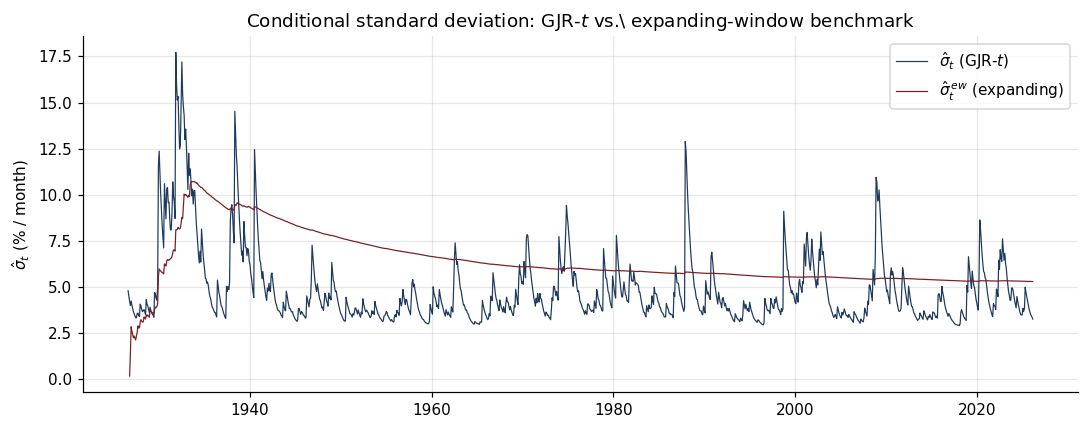

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sigma_hat.index, sigma_hat, lw=0.8, color="#1f3a5f", label=r"$\hat\sigma_t$ (GJR-$t$)")
ax.plot(expanding_sd.index, expanding_sd, lw=0.8, color="#7a1f1f", label=r"$\hat\sigma_t^{\,ew}$ (expanding)")
ax.set_ylabel(r"$\hat\sigma_t$ (% / month)"); ax.legend(loc="upper right")
ax.set_title(r"Conditional standard deviation: GJR-$t$ vs.\ expanding-window benchmark")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig3_sigma.pdf", bbox_inches="tight"); plt.show()

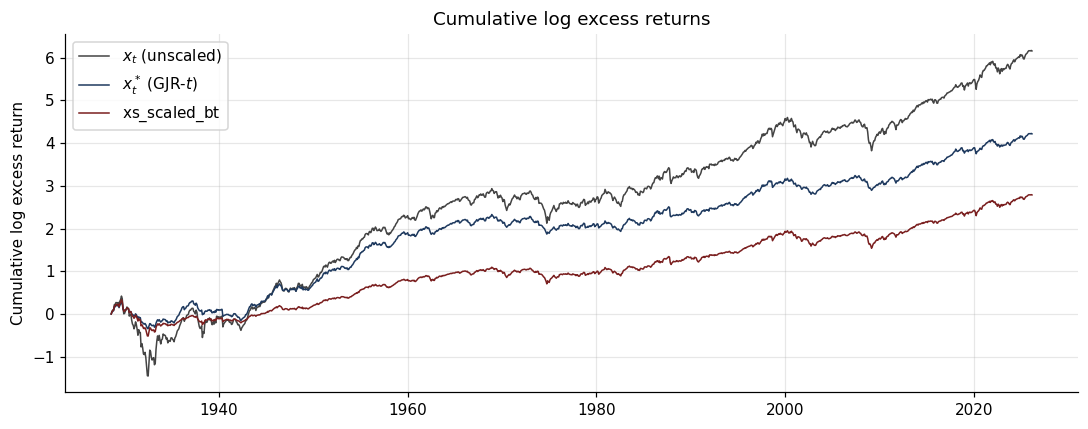

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
for col, lbl, color in [
    ("x",      r"$x_t$ (unscaled)",        "#444444"),
    ("x_star", r"$x^*_t$ (GJR-$t$)",       "#1f3a5f"),
    ("xs_bt",  r"$\text{xs\_scaled\_bt}$","#7a1f1f"),
]:
    ax.plot(panel.index, panel[col].cumsum()/100, lw=1.0, label=lbl, color=color)
ax.set_ylabel("Cumulative log excess return"); ax.legend(loc="upper left")
ax.set_title("Cumulative log excess returns")
fig.tight_layout(); fig.savefig(FIGURE_DIR / "fig4_cumret.pdf", bbox_inches="tight"); plt.show()

All tables (`tables/*.tex`) and figures (`figures/*.pdf`) regenerated.